In [ ]:
!pip install sentence-transformers
!pip install seaborn matplotlib

from sentence_transformers import SentenceTransformer, util
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
sentences = [
    # Cricket (3 sentences)
    "The batsman scored a century in the final match.",
    "The cricket team practiced fielding drills all morning.",
    "The fast bowler delivered an impressive spell with swing and pace.",

    # Cooking (3 sentences)
    "The chef prepared a creamy pasta using fresh ingredients.",
    "Slow cooking enhances the flavor of tender meat dishes.",
    "She baked a chocolate cake topped with roasted almonds.",

    # Cybersecurity (4 sentences)
    "The firewall blocked unauthorized access attempts.",
    "Phishing attacks often trick users into revealing passwords.",
    "Encryption ensures that sensitive data remains protected.",
    "Cybersecurity analysts monitor networks for suspicious activity."
]

In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)
embeddings.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

torch.Size([10, 384])

In [8]:
similarity_matrix = util.cos_sim(embeddings, embeddings).cpu().numpy()
similarity_matrix

array([[ 1.        ,  0.36772913,  0.4447059 , -0.01437337,  0.04521167,
         0.04501448, -0.01951586, -0.00814607,  0.01259827, -0.03835922],
       [ 0.36772913,  1.        ,  0.39021367, -0.00658264,  0.09764242,
        -0.05484561,  0.01112648,  0.08163896, -0.04918081,  0.11845299],
       [ 0.4447059 ,  0.39021367,  0.9999999 ,  0.12989804,  0.15275702,
         0.10204519,  0.01665664,  0.079293  , -0.04608361,  0.00865318],
       [-0.01437337, -0.00658264,  0.12989804,  1.        ,  0.36937052,
         0.31189394,  0.01696516, -0.03930577, -0.00166273,  0.0044931 ],
       [ 0.04521167,  0.09764242,  0.15275702,  0.36937052,  1.        ,
         0.15822488,  0.053355  ,  0.11799932,  0.05228584, -0.01413539],
       [ 0.04501448, -0.05484561,  0.10204519,  0.31189394,  0.15822488,
         1.0000002 ,  0.08092706,  0.07966938,  0.02165018, -0.02929692],
       [-0.01951586,  0.01112648,  0.01665664,  0.01696516,  0.053355  ,
         0.08092706,  1.0000004 ,  0.26517153

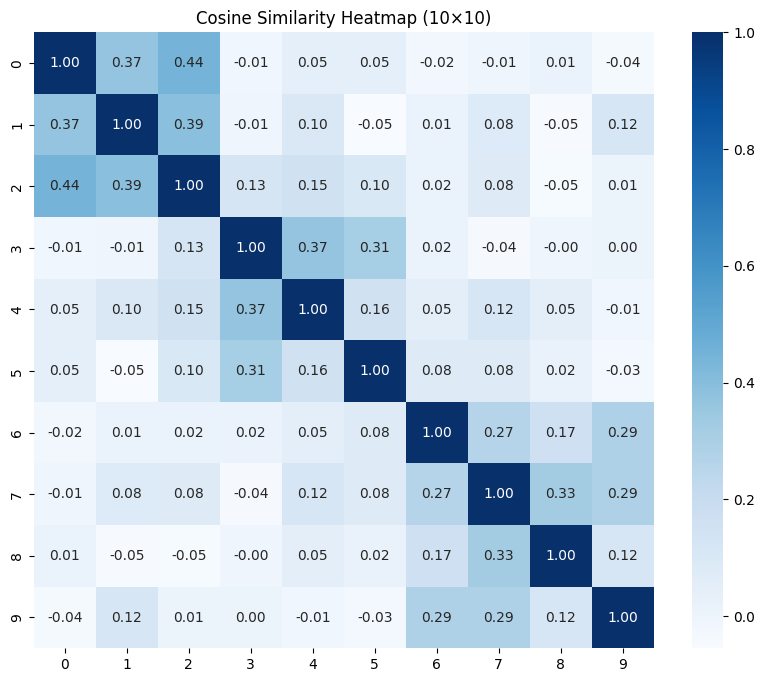

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cosine Similarity Heatmap (10×10)")
plt.show()

In [10]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity with all 10 sentences
scores = util.cos_sim(query_embedding, embeddings)[0].cpu().numpy()

# Get top 2 most similar sentences
top_indices = scores.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {scores[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The fast bowler delivered an impressive spell with swing and pace.
Similarity Score: 0.5839

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679

